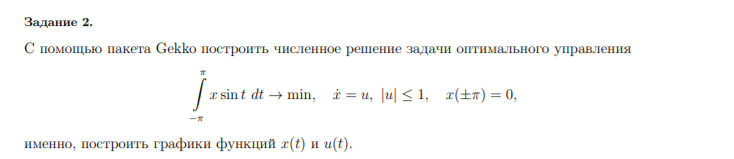

In [6]:
from gekko import GEKKO
import numpy as np
import matplotlib.pyplot as plt

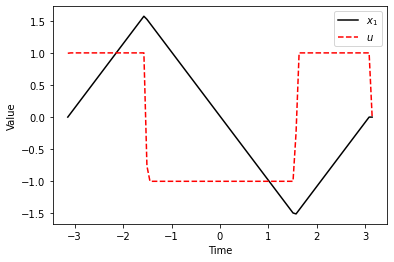

In [8]:
m = GEKKO() # initialize gekko
nt = 101
T=np.pi
#T=5
m.time = np.linspace(-T,T,nt) # время на отрезке
end_loc = nt-1

# Variables
x1 = m.Var(value=0)
x2 = m.Var(value=0)

#u = m.Var(value=0,lb=-1,ub=1)
u = m.MV(fixed_initial=False,lb=-1,ub=1)
u.STATUS = 1


p = np.zeros(nt) # mark final time point
p[-1] = 1.0 # вектор длины nt вида (0; ... 0;1)
final = m.Param(value=p)
t = m.Param(value=m.time)
sint=m.Param(value=np.sin(t))

# Equations
m.Equation(x1.dt()==u)
m.Equation(x2.dt()==x1*sint)
m.fix(x1,pos=end_loc,val=0.0) # условие в правом конце

m.Obj(x2*final) # Objective function, x2*final --- последняя компонента вектора x2
m.options.IMODE = 5 # optimal control mode
m.solve(disp=False) # solve

plt.figure(1) # plot results
plt.plot(m.time,x1.value,'k-',label=r'$x_1$')
#plt.plot(m.time,x2.value,'b-',label=r'$x_2$')
plt.plot(m.time,u.value,'r--',label=r'$u$')
plt.legend(loc='best')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()